## Pre-requisites

Before running this notebook, you should have already used the `extract_features.py` script to extract features from models trained on DHS data. You should have the following structure under the `final_ex/income/` directory:

```
dhs_incountry/
    DHS_Incountry_A_ms_samescaled_b64_fc01_conv01_lr001/
        features.npz
    ...
    DHS_Incountry_C_ms_samescaled_250_b64_fc1.0_conv1/
        features.npz
    ...
    DHS_Incountry_E_nl_random_b64_fc01_conv01_lr001/
        features.npz
```

## Instructions

This notebook essentially performs fine-tuning of the final-layer of the Resnet-18 models. However, instead of directly fine-tuning the Resnet-18 models in TensorFlow, we train ridge-regression models using the extracted features. We take this approach for two reasons:

1. It is easier to perform leave-one-group-out ("logo") cross-validated ridge regression using scikit-learn, as opposed to TensorFlow. For out-of-country (OOC) experiments, the left-out group is the test country. For in-country experiments, the left-out group is the test split.
2. We can concatenate the 512-dim features from the RGB/MS CNN models with the 512-dim features from the NL CNN models to form a larger 1024-dim feature vector capturing RGB/MS + NL imagery information. We do this instead of training a CNN with the MS+NL imagery stacked together as an input because we found it to result in better performance.


## Imports and Constants

### Install Libraries

### Imports

In [2]:
#from __future__ import annotations

from collections.abc import Iterable
import os
import pickle

import numpy as np
import pandas as pd

from batchers import dataset_constants
from models.linear_model import ridge_cv
from utils.general import load_npz

### Important constants and Paths

In [3]:
FOLDS = ['A', 'B', 'C', 'D', 'E']
SPLITS = ['train', 'val', 'test']
label = 'income'
OUTPUTS_ROOT_DIR = f'/home/sagemaker-user/reproducible/logs/{label}'
INPUTS_ROOT_DIR = f'/home/sagemaker-user/reproducible/final_ex/{label}'
INPUTS_ROOT_DIR_RANDOM = f'/home/sagemaker-user/reproducible/final_ex'
COUNTRIES = dataset_constants.DHS_COUNTRIES

KEEPS = [0.05, 0.1, 0.25, 0.5]
SEEDS = [123, 456, 789]

## Load data

In [4]:
MODEL_DIRS = {
    #Incountry models - NightLight
    
    'incountry_resnet_nl_A':'DHS_Incountry_A_nl_random_b64_fc1.0_conv1.0_lr0001',
    'incountry_resnet_nl_B':'DHS_Incountry_B_nl_random_b64_fc1.0_conv1.0_lr0001',
    'incountry_resnet_nl_C':'DHS_Incountry_C_nl_random_b64_fc1.0_conv1.0_lr0001',
    'incountry_resnet_nl_D':'DHS_Incountry_D_nl_random_b64_fc1.0_conv1.0_lr0001',
    'incountry_resnet_nl_E':'DHS_Incountry_E_nl_random_b64_fc1_conv1.0_lr001',
    
    # Incountry models - MultiSpectral
    
    'incountry_resnet_ms_A':'DHS_Incountry_A_ms_samescaled_200_b64_fc01_conv01_lr001',
    'incountry_resnet_ms_B':'DHS_Incountry_B_ms_samescaled_200_b64_fc1_conv1_lr001',
    'incountry_resnet_ms_C':'DHS_Incountry_C_ms_samescaled_200_b64_fc1.0_conv1.0_lr0001',
    'incountry_resnet_ms_D':'DHS_Incountry_D_ms_samescaled_200_b64_fc001_conv1.0_lr0001',
    'incountry_resnet_ms_E':'DHS_Incountry_E_ms_samescaled_200_b64_fc001_conv001_lr0001',
    
    # Incountry models - MultiSpectral with 250 epochs
    
    #'incountry_resnet_ms_250_A':'DHS_Incountry_A_ms_samescaled_250_b64_fc01_conv01_lr001',
    #'incountry_resnet_ms_250_B':'DHS_Incountry_B_ms_samescaled_250_b64_fc1_conv1_lr001',
    #'incountry_resnet_ms_250_C':'DHS_Incountry_C_ms_samescaled_250_b64_fc1.0_conv1.0_lr0001',
    #'incountry_resnet_ms_250_D':'DHS_Incountry_D_ms_samescaled_250_b64_fc001_conv1.0_lr0001',
    #'incountry_resnet_ms_250_E':'DHS_Incountry_E_ms_samescaled_250_b64_fc001_conv001_lr0001',
}

`country_labels` is a `np.ndarray` that shows which country each cluster belongs to. Countries are indexed by their position in `dataset_constants.DHS_COUNTRIES`.
```python
array([ 0,  0,  0, ..., 22, 22, 22])
```

`incountry_group_labels` is a `np.ndarray` that shows which "test" fold each cluster belongs to. The first cluster belongs to the "test" split of fold "B" (folds here are 0-indexed).
```python
array([1, 1, 4, ..., 1, 0, 3])
```

### Check Number of Countries

In [5]:
countries=["brazil"]

print(len(countries))

1


### Check Indicators

In [6]:
FOLDS = ["A", "B", "C", "D", "E"]
indicators = ['income','longevity','literacy']
for label in indicators:
    df = pd.read_csv('/home/sagemaker-user/reproducible/data/processed/clusters_data_9000.0km.csv', float_precision='high', index_col=False)
    labels = df[label].to_numpy(dtype=np.float32)
    print(labels)

[0.58993196 0.66502625 0.5748903  ... 0.58242553 0.62456554 0.6280874 ]
[0.78758115 0.87809706 0.7833495  ... 0.6792194  0.77019185 0.7842221 ]
[0.9344155  0.9346706  0.87228996 ... 0.90469867 0.94811887 0.9426079 ]


### Extract Indicators, location and country names in the correct order

In [7]:
label = 'income'

print(f'for label {label}:')
print(f'dhs_co_{label}.npz Dictionary Key, Value Type and Shape')
df = pd.read_csv('/home/sagemaker-user/reproducible/data/processed/clusters_data_9000.0km.csv', float_precision='high', index_col=False)
npz = load_npz('/home/sagemaker-user/reproducible/data/processed/dhs_co_income.npz')
labels = npz['labels']
print(labels)
print(len(labels))
locs = npz['locs']
country_labels = df['country'].map(countries.index).to_numpy()
print(country_labels)

for label income:
dhs_co_income.npz Dictionary Key, Value Type and Shape
image_hists: dtype=int64, shape=(23675, 8, 102)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
nls_center: dtype=float32, shape=(23675,)
nls_mean: dtype=float32, shape=(23675,)
[0.33520263 0.30585873 0.35464624 ... 0.5176941  0.5820697  0.44908533]
23675
[0 0 0 ... 0 0 0]


### Get the test split indices for each fold.

In [8]:
with open('/home/sagemaker-user/reproducible/data/processed/dhs_incountry_co.pkl', 'rb') as f:
    incountry_folds = pickle.load(f)
incountry_group_labels = np.zeros(len(df), dtype=np.int64)
print('Indices for each Fold')
print()
for i, fold in enumerate(FOLDS):
    test_indices = incountry_folds[fold]['test']
    print(f'For Fold {FOLDS[i]}')
    print(test_indices)
    incountry_group_labels[test_indices] = i
    

Indices for each Fold

For Fold A
[   26    29    35 ... 23674 23705 23709]
For Fold B
[   11    57    60 ... 23702 23710 23715]
For Fold C
[    0     3     4 ... 23716 23717 23718]
For Fold D
[    6     9    10 ... 23685 23690 23691]
For Fold E
[    1     2    16 ... 23712 23713 23714]


Figure - Incountry Clusters split by Folds
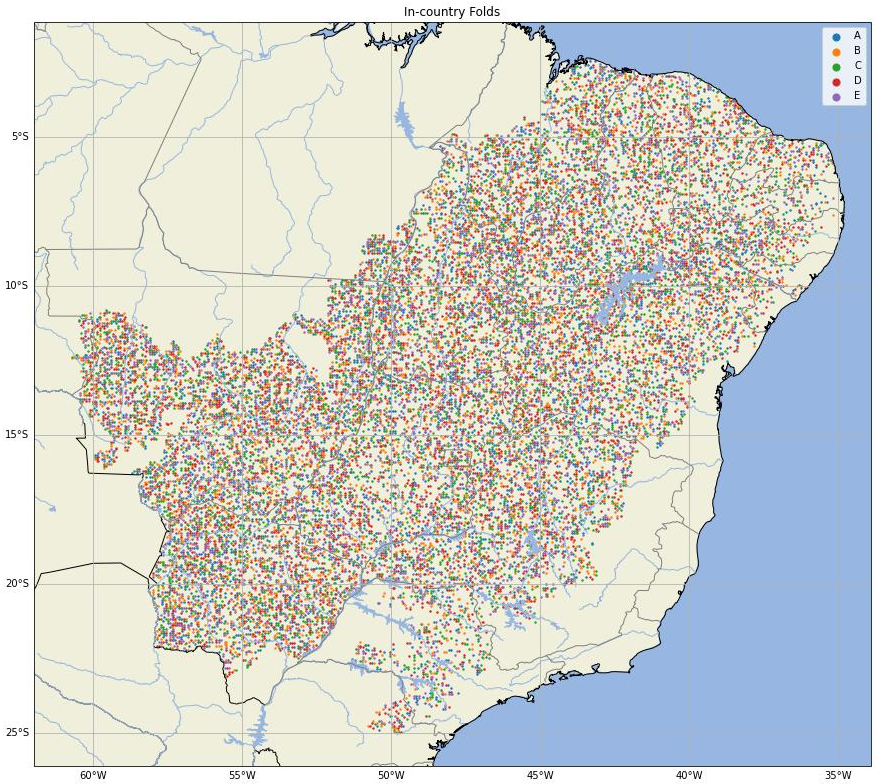

## Incountry

### Ridge Regression using only the best set

In [9]:
f = 'E'
num_examples = len(labels)
model_name = 'incountry_resnet_ms'
model_fold_name = f'{model_name}_{f}'
print(model_fold_name)
model_dir = MODEL_DIRS[model_fold_name]
npz_path = os.path.join(INPUTS_ROOT_DIR, 'dhsincountry', model_dir, 'features.npz')
print(npz_path)
print(labels)
npz = load_npz(npz_path, check={'labels': labels})
features = npz['features']

incountry_resnet_ms_E
/home/sagemaker-user/reproducible/final_ex/income/dhsincountry/DHS_Incountry_E_ms_samescaled_200_b64_fc001_conv001_lr0001/features.npz
[0.33520263 0.30585873 0.35464624 ... 0.5176941  0.5820697  0.44908533]
features: dtype=float32, shape=(23675, 512)
preds: dtype=float32, shape=(23675,)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)


In [10]:
#!!
# Tamanho máximo permitido com base no shape de features
max_size = features.shape[0]

# Para cada fold, removendo índices que são maiores que o permitido
for fold in incountry_folds:
    # Filtrar índices de treino
    train_indices = incountry_folds[fold]['train']
    filtered_train_indices = [idx for idx in train_indices if idx < max_size]
    incountry_folds[fold]['train'] = filtered_train_indices

    # Filtrar índices de validação
    val_indices = incountry_folds[fold]['val']
    filtered_val_indices = [idx for idx in val_indices if idx < max_size]
    incountry_folds[fold]['val'] = filtered_val_indices

    # Filtrar índices de teste
    test_indices = incountry_folds[fold]['test']
    filtered_test_indices = [idx for idx in test_indices if idx < max_size]
    incountry_folds[fold]['test'] = filtered_test_indices

    print(f"Fold {fold} - Índices de treino, validação e teste atualizados")


Fold A - Índices de treino, validação e teste atualizados
Fold B - Índices de treino, validação e teste atualizados
Fold C - Índices de treino, validação e teste atualizados
Fold D - Índices de treino, validação e teste atualizados
Fold E - Índices de treino, validação e teste atualizados


In [11]:
from models.linear_model import ridge_cv, train_linear_model
import sklearn.linear_model

In [12]:

X = features[np.arange(num_examples)]
y = labels[np.arange(num_examples)]
X_train = features[incountry_folds[f]['train']]
y_train = labels[incountry_folds[f]['train']]
X_val = features[incountry_folds[f]['val']]
y_val = labels[incountry_folds[f]['val']]
X_test = features[incountry_folds[f]['test']]
y_test = labels[incountry_folds[f]['test']]

best_model, best_train_preds, best_val_preds = train_linear_model(X_train, y_train, X_val, y_val,
                       linear_model=sklearn.linear_model.Ridge,
                       plot_alphas=False, optimize='r2')

test_preds = best_model.predict(X)

savedir = os.path.join(OUTPUTS_ROOT_DIR, 'resnet_ms/only_e')
filename = 'test_preds.npz'
npz_path = os.path.join(savedir, filename)
save_dict = {}
if savedir is not None:
        os.makedirs(savedir, exist_ok=True)

        # build up save_dict
        if 'labels' in save_dict:
            assert np.array_equal(labels, save_dict['labels'])
        save_dict['labels'] = labels
        save_dict['test_preds'] = test_preds

        print('saving test preds to:', npz_path)
        np.savez_compressed(npz_path, **save_dict)

/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/scipy/stats/stats.py:3845: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/scipy/stats/stats.py:3845: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/scipy/stats/stats.py:3845: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/scipy/stats/stats.py:3845: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRCons

saving test preds to: /home/sagemaker-user/reproducible/logs/income/resnet_ms/only_e/test_preds.npz


In [13]:
# !!# for fold in incountry_folds:
#     train_indices = incountry_folds[fold]['train']
#     val_indices = incountry_folds[fold]['val']
#     if max(train_indices) >= features.shape[0] or max(val_indices) >= features.shape[0]:
#         print(f"Índice fora do limite no fold {fold}")

# print(features.shape)

### Ridge Regression with k-Fold Cross Validation for ResNet-NL and ResNet-MS models

In [14]:
def ridgecv_incountry_wrapper(model_name: str, savedir: str) -> None:
    '''
    Args
    - model_name: str, corresponds to keys in MODEL_DIRS (without the fold suffix)
    - savedir: str, path to directory for saving ridge regression weights and predictions
    '''
    print(INPUTS_ROOT_DIR)
    features_dict = {}
    for f in FOLDS:
        model_fold_name = f'{model_name}_{f}'
        
        model_dir = MODEL_DIRS[model_fold_name]
        if 'random' in model_dir:
            npz_path = os.path.join(INPUTS_ROOT_DIR_RANDOM, 'dhsincountry', model_dir, 'features.npz')
        else:
            npz_path = os.path.join(INPUTS_ROOT_DIR, 'dhsincountry', model_dir, 'features.npz')
        print(labels)
        npz = load_npz(npz_path, check={'labels': labels})
        features_dict[f] = npz['features']

    ridge_cv(
        features=features_dict,
        labels=labels,
        group_labels=incountry_group_labels,
        group_names=FOLDS,
        do_plot=True,
        savedir=savedir,
        save_weights=True,
        verbose=True)

### Ridge Regression with k-Fold Cross Validation for ResNet-MS

In [15]:
import os

npz_path = os.path.join(savedir, 'ridge_weights.npz')
if os.path.exists(npz_path):
    new_npz_path = npz_path.replace('.npz', '_backup.npz')
    os.rename(npz_path, new_npz_path)
    print(f"Arquivo {npz_path} renomeado para {new_npz_path}")

import glob
import os

# Caminho para os arquivos .npz no diretório de saída
npz_files = glob.glob(os.path.join(savedir, '*.npz'))

# Remover ou renomear todos os arquivos .npz
for npz_file in npz_files:
    os.remove(npz_file)
    print(f"Arquivo {npz_file} removido")

Arquivo /home/sagemaker-user/reproducible/logs/income/resnet_ms/only_e/test_preds.npz removido


/home/sagemaker-user/reproducible/final_ex/income
[0.33520263 0.30585873 0.35464624 ... 0.5176941  0.5820697  0.44908533]
features: dtype=float32, shape=(23675, 512)
preds: dtype=float32, shape=(23675,)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
[0.33520263 0.30585873 0.35464624 ... 0.5176941  0.5820697  0.44908533]
features: dtype=float32, shape=(23675, 512)
preds: dtype=float32, shape=(23675,)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
[0.33520263 0.30585873 0.35464624 ... 0.5176941  0.5820697  0.44908533]
features: dtype=float32, shape=(23675, 512)
preds: dtype=float32, shape=(23675,)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
[0.33520263 0.30585873 0.35464624 ... 0.5176941  0.5820697  0.44908533]
features: dtype=float32, shape=(23675, 512)
preds: dtype=float32, shape=(23675,)
label

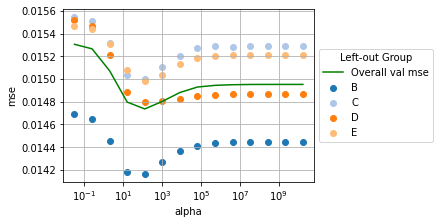

best val mse: 0.015, best alpha: 128.0, test mse: 0.016
Group: B
Alpha: 17179869184.0 (14/14)
best val mse: 0.015, best alpha: 128.0, test mse: 0.014
Group: C
Alpha: 17179869184.0 (14/14)
best val mse: 0.015, best alpha: 128.0, test mse: 0.015
Group: D
Alpha: 17179869184.0 (14/14)
best val mse: 0.015, best alpha: 128.0, test mse: 0.015
Group: E
Alpha: 17179869184.0 (14/14)
best val mse: 0.015, best alpha: 0.03125, test mse: 0.015
saving test preds to: /home/sagemaker-user/reproducible/logs/income/resnet_nl/test_preds.npz
saving ridge_weights to: /home/sagemaker-user/reproducible/logs/income/resnet_nl/ridge_weights.npz


In [16]:
model_name = 'incountry_resnet_nl'
savedir = os.path.join(OUTPUTS_ROOT_DIR, 'resnet_nl')
ridgecv_incountry_wrapper(model_name, savedir)

/home/sagemaker-user/reproducible/final_ex/income
[0.33520263 0.30585873 0.35464624 ... 0.5176941  0.5820697  0.44908533]
features: dtype=float32, shape=(23675, 512)
preds: dtype=float32, shape=(23675,)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
[0.33520263 0.30585873 0.35464624 ... 0.5176941  0.5820697  0.44908533]
features: dtype=float32, shape=(23675, 512)
preds: dtype=float32, shape=(23675,)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
[0.33520263 0.30585873 0.35464624 ... 0.5176941  0.5820697  0.44908533]
features: dtype=float32, shape=(23675, 512)
preds: dtype=float32, shape=(23675,)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
[0.33520263 0.30585873 0.35464624 ... 0.5176941  0.5820697  0.44908533]
features: dtype=float32, shape=(23675, 512)
preds: dtype=float32, shape=(23675,)
label

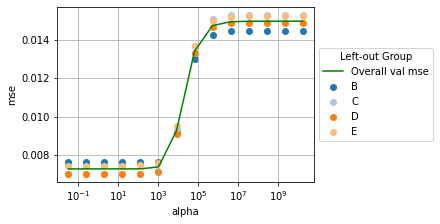

best val mse: 0.007, best alpha: 0.03125, test mse: 0.008
Group: B
Alpha: 17179869184.0 (14/14)
best val mse: 0.008, best alpha: 0.25, test mse: 0.008
Group: C
Alpha: 17179869184.0 (14/14)
best val mse: 0.009, best alpha: 0.03125, test mse: 0.008
Group: D
Alpha: 17179869184.0 (14/14)
best val mse: 0.008, best alpha: 0.25, test mse: 0.007
Group: E
Alpha: 17179869184.0 (14/14)
best val mse: 0.006, best alpha: 0.03125, test mse: 0.006
saving test preds to: /home/sagemaker-user/reproducible/logs/income/resnet_ms/test_preds.npz
saving ridge_weights to: /home/sagemaker-user/reproducible/logs/income/resnet_ms/ridge_weights.npz


In [17]:
model_name = 'incountry_resnet_ms'
savedir = os.path.join(OUTPUTS_ROOT_DIR, 'resnet_ms')
ridgecv_incountry_wrapper(model_name, savedir)

# Concatenated MS + NL Features

In [18]:
def ridgecv_incountry_concat_wrapper(model_names, savedir) -> None:
    '''
    Args
    - model_names: list of str, correspond to keys in MODEL_DIRS (without the fold suffix)
    - savedir: str, path to directory for saving ridge regression weights and predictions
    '''
    features_dict = {}
    for i, f in enumerate(FOLDS):
        concat_features = []  # list of np.array, each shape [N, D_i]
        for model_name in model_names:
            print(model_name)
            model_dir = MODEL_DIRS[f'{model_name}_{f}']
            if 'random' in model_dir:
                npz_path = os.path.join(INPUTS_ROOT_DIR_RANDOM, 'dhsincountry', model_dir, 'features.npz')
            else:
                npz_path = os.path.join(INPUTS_ROOT_DIR, 'dhsincountry', model_dir, 'features.npz')
            npz = load_npz(npz_path, check={'labels': labels})
            concat_features.append(npz['features'])
        concat_features = np.concatenate(concat_features, axis=1)  # shape [N, D_1 + ... + D_m]
        features_dict[f] = concat_features

    ridge_cv(
        features=features_dict,
        labels=labels,
        group_labels=incountry_group_labels,
        group_names=FOLDS,
        do_plot=True,
        savedir=savedir,
        save_weights=True,
        verbose=True)


incountry_resnet_ms
features: dtype=float32, shape=(23675, 512)
preds: dtype=float32, shape=(23675,)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
incountry_resnet_nl
features: dtype=float32, shape=(23675, 512)
preds: dtype=float32, shape=(23675,)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
incountry_resnet_ms
features: dtype=float32, shape=(23675, 512)
preds: dtype=float32, shape=(23675,)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
incountry_resnet_nl
features: dtype=float32, shape=(23675, 512)
preds: dtype=float32, shape=(23675,)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
incountry_resnet_ms
features: dtype=float32, shape=(23675, 512)
preds: dtype=float32, shape=(23675,)
labels: dtype=float32, shape=(23675,)
locs: dtype=f

/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=1.05044e-08): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=1.09255e-08): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=1.10522e-08): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=1.11003e-08): result may not be accurate.
  overwrite_a=True).T


Alpha: 17179869184.0 (14/14)


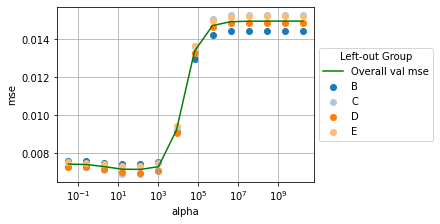

best val mse: 0.007, best alpha: 128.0, test mse: 0.008
Group: B
Alpha: 0.03125 (1/14)

/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=7.17416e-09): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=6.95056e-09): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=7.04404e-09): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=7.05554e-09): result may not be accurate.
  overwrite_a=True).T


Alpha: 17179869184.0 (14/14)
best val mse: 0.008, best alpha: 16.0, test mse: 0.008
Group: C
Alpha: 0.03125 (1/14)

/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.11699e-08): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=1.94758e-08): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.05587e-08): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.08129e-08): result may not be accurate.
  overwrite_a=True).T


Alpha: 17179869184.0 (14/14)
best val mse: 0.009, best alpha: 16.0, test mse: 0.008
Group: D
Alpha: 0.03125 (1/14)

/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=8.03135e-09): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=7.39835e-09): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=7.72088e-09): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=7.82971e-09): result may not be accurate.
  overwrite_a=True).T


Alpha: 0.25 (2/14)

/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.503e-08): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.30937e-08): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.40633e-08): result may not be accurate.
  overwrite_a=True).T
/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.44634e-08): result may not be accurate.
  overwrite_a=True).T


Alpha: 17179869184.0 (14/14)
best val mse: 0.008, best alpha: 2.0, test mse: 0.007
Group: E
Alpha: 17179869184.0 (14/14)
best val mse: 0.006, best alpha: 0.03125, test mse: 0.006
saving test preds to: /home/sagemaker-user/reproducible/logs/income/resnet_msnl_concat/test_preds.npz
saving ridge_weights to: /home/sagemaker-user/reproducible/logs/income/resnet_msnl_concat/ridge_weights.npz


In [19]:
model_names = ['incountry_resnet_ms', 'incountry_resnet_nl']
savedir = os.path.join(OUTPUTS_ROOT_DIR, 'resnet_msnl_concat')

# Assuming the training function is executed here
ridgecv_incountry_concat_wrapper(model_names, savedir)